In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

--2026-05-19 21:21:23--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 21:21:24--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-19 21:21:24 (4.44 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 21:21:24--  https://github.com/AllenDo

# 9.1

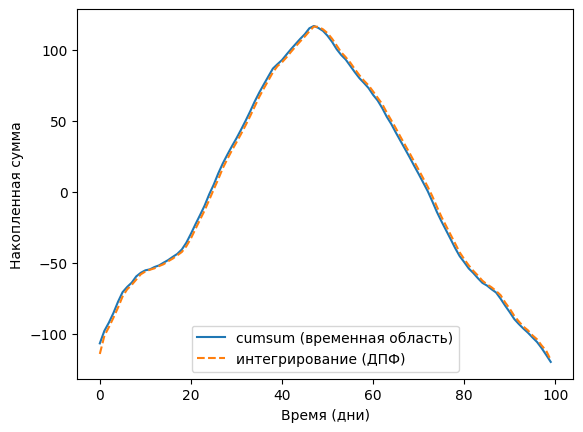

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if not os.path.exists('FB_2.csv'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/FB_2.csv

df = pd.read_csv('FB_2.csv', header=0, parse_dates=[0])
yss = df['Close'].values
yss_short = yss[:100]
wave = thinkdsp.Wave(yss_short, framerate=1)
wave.unbias()
# 1. Нарастающая сумма (cumsum) – эталон
cumsum_wave = wave.cumsum()
cumsum_wave.unbias()

# 2. Интегрирование через ДПФ (ручное)
N = len(yss_short)
hs = np.fft.rfft(wave.ys)                     # прямое ДПФ
freqs = np.fft.rfftfreq(N, d=1.0)         # частоты (Гц, т.к. framerate=1)
hs_int = hs.copy()
hs_int[0] = 0.0                           # постоянная составляющая = 0
hs_int[1:] /= (2j * np.pi * freqs[1:])    # интегрирование
ys_int = np.fft.irfft(hs_int, n=N)        # обратное ДПФ
integrated_wave = thinkdsp.Wave(ys_int, framerate=1)
integrated_wave.unbias()

# Построение графиков (первые 200 точек)
plt.plot(cumsum_wave.ys[:200], label='cumsum (временная область)')
plt.plot(integrated_wave.ys[:200], '--', label='интегрирование (ДПФ)')
plt.xlabel('Время (дни)')
plt.ylabel('Накопленная сумма')
plt.legend()
plt.show()

Есть небольшие расхождения по краям

# 9.2

Корреляция между diff и ручным differentiate: 0.9968


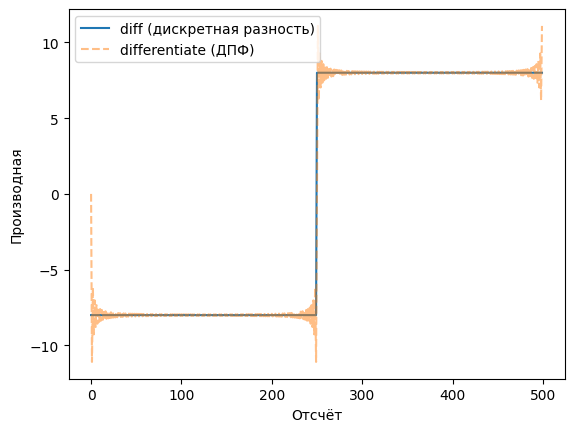

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Треугольный сигнал 2 Гц, 10 секунд
signal = thinkdsp.TriangleSignal(freq=2)
wave = signal.make_wave(duration=10, framerate=1000)
wave.unbias()

# 1. Производная через diff (с учётом шага времени)
dt = 1 / wave.framerate
diff_ys = np.diff(wave.ys) / dt
diff_wave = thinkdsp.Wave(diff_ys, framerate=wave.framerate)

# 2. Производная через ДПФ (ручное дифференцирование)
N = len(wave.ys)
hs = np.fft.rfft(wave.ys)
freqs = np.fft.rfftfreq(N, d=dt)
hs_deriv = hs * (2j * np.pi * freqs)
hs_deriv[0] = 0   # обнуляем постоянную составляющую
ys_deriv = np.fft.irfft(hs_deriv, n=N)
deriv_wave = thinkdsp.Wave(ys_deriv, framerate=wave.framerate)
deriv_wave.unbias()

# Приводим к одинаковой длине (diff короче на 1)
min_len = min(len(diff_ys), len(ys_deriv))
diff_aligned = diff_ys[:min_len]
deriv_aligned = ys_deriv[:min_len]

# Корреляция
corr = np.corrcoef(diff_aligned, deriv_aligned)[0,1]
print(f"Корреляция между diff и ручным differentiate: {corr:.4f}")

# График первых 500 точек
plt.plot(diff_aligned[:500], label='diff (дискретная разность)')
plt.plot(deriv_aligned[:500], '--', label='differentiate (ДПФ)', alpha = 0.5)
plt.xlabel('Отсчёт')
plt.ylabel('Производная')
plt.legend()
plt.show()

# 9.3

Корреляция: 1.0000


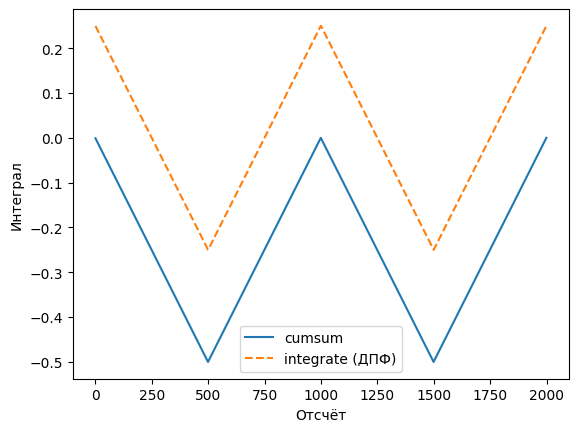

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Прямоугольный сигнал (меандр) 1 Гц, 10 секунд, 1000 Гц
square = thinkdsp.SquareSignal(freq=1)
wave = square.make_wave(duration=10, framerate=1000)
wave.unbias()

# 1. Интегрирование через cumsum (временная область)
dt = 1 / wave.framerate
cum_ys = np.cumsum(wave.ys) * dt
cum_wave = thinkdsp.Wave(cum_ys, framerate=wave.framerate)

# 2. Интегрирование через ДПФ (частотная область)
N = len(wave.ys)
hs = np.fft.rfft(wave.ys)
freqs = np.fft.rfftfreq(N, d=dt)
hs_int = hs.copy()
hs_int[0] = 0.0
hs_int[1:] /= (2j * np.pi * freqs[1:])
ys_int = np.fft.irfft(hs_int, n=N)
int_wave = thinkdsp.Wave(ys_int, framerate=wave.framerate)

# Корреляция (длины совпадают)
corr = np.corrcoef(cum_ys, ys_int)[0,1]
print(f"Корреляция: {corr:.4f}")

# График первых 2000 точек (2 секунды)
plt.plot(cum_ys[:2000], label='cumsum')
plt.plot(ys_int[:2000], '--', label='integrate (ДПФ)')
plt.xlabel('Отсчёт')
plt.ylabel('Интеграл')
plt.legend()
plt.show()

# 9.4

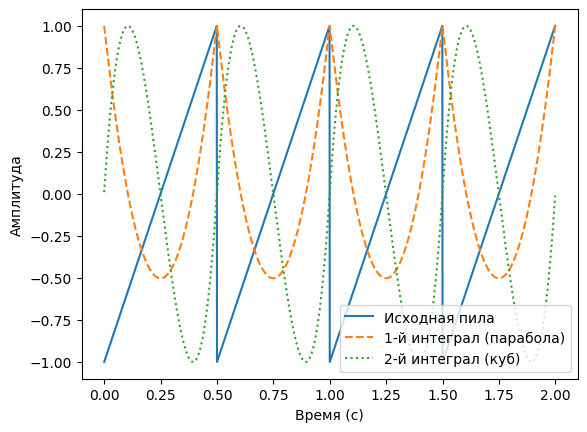

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def integrate_wave(wave):
    """Интегрирование через ДПФ, возвращает новый Wave."""
    dt = 1 / wave.framerate
    N = len(wave.ys)
    hs = np.fft.rfft(wave.ys)
    freqs = np.fft.rfftfreq(N, d=dt)
    hs_int = hs.copy()
    hs_int[0] = 0.0
    hs_int[1:] /= (2j * np.pi * freqs[1:])
    ys_int = np.fft.irfft(hs_int, n=N)
    return thinkdsp.Wave(ys_int, framerate=wave.framerate)

# Пилообразный сигнал 2 Гц
saw = thinkdsp.SawtoothSignal(freq=2)
wave = saw.make_wave(duration=5, framerate=1000)
wave.unbias()

int1 = integrate_wave(wave)
int1.unbias()
int2 = integrate_wave(int1)
int2.unbias()

# Нормализация для наглядности
wave.normalize()
int1.normalize()
int2.normalize()

# Построение
t = np.arange(2000) / wave.framerate
plt.plot(t, wave.ys[:2000], label='Исходная пила')
plt.plot(t, int1.ys[:2000], '--', label='1-й интеграл (парабола)')
plt.plot(t, int2.ys[:2000], ':', label='2-й интеграл (куб)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()

# 9.5

Корреляция между второй разностью и второй производной: 0.9933


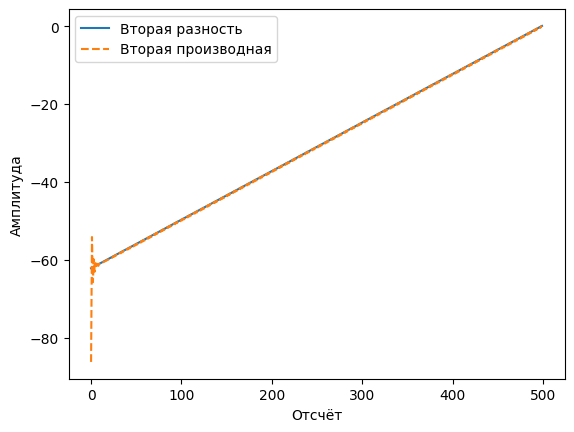

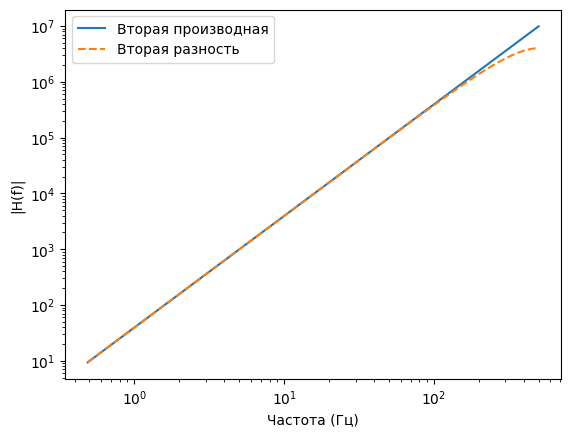

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def differentiate_wave(wave):
    """Дифференцирование через ДПФ, возвращает новый Wave."""
    dt = 1 / wave.framerate
    N = len(wave.ys)
    hs = np.fft.rfft(wave.ys)
    freqs = np.fft.rfftfreq(N, d=dt)
    hs_deriv = hs * (2j * np.pi * freqs)
    hs_deriv[0] = 0
    ys_deriv = np.fft.irfft(hs_deriv, n=N)
    return thinkdsp.Wave(ys_deriv, framerate=wave.framerate)

# CubicSignal (периодический кубический полином)
cubic = thinkdsp.CubicSignal(freq=1)
wave = cubic.make_wave(duration=4, framerate=1000)
wave.unbias()

# Вторая разность (дискретная, с учётом dt)
dt = 1 / wave.framerate
diff1 = np.diff(wave.ys) / dt
diff2 = np.diff(diff1) / dt
second_diff = thinkdsp.Wave(diff2, framerate=wave.framerate)

# Вторая производная через ДПФ
deriv1 = differentiate_wave(wave)
deriv2 = differentiate_wave(deriv1)

# Обрезаем до одинаковой длины (вторая разность короче на 2)
min_len = min(len(second_diff.ys), len(deriv2.ys))
diff_aligned = second_diff.ys[:min_len]
deriv_aligned = deriv2.ys[:min_len]

corr = np.corrcoef(diff_aligned, deriv_aligned)[0,1]
print(f"Корреляция между второй разностью и второй производной: {corr:.4f}")

# График
plt.plot(diff_aligned[:500], label='Вторая разность')
plt.plot(deriv_aligned[:500], '--', label='Вторая производная')
plt.xlabel('Отсчёт')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()

# Частотные характеристики фильтров
N_fft = 2048
freq = np.fft.rfftfreq(N_fft, d=dt)
H_deriv = (2 * np.pi * freq)**2
H_diff = (2 - 2 * np.cos(2 * np.pi * freq * dt)) / dt**2

plt.loglog(freq[1:], H_deriv[1:], label='Вторая производная')
plt.loglog(freq[1:], H_diff[1:], '--', label='Вторая разность')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H(f)|')
plt.legend()
plt.show()